<a href="https://colab.research.google.com/github/ChandikaGanewatte/Code_Review_Assitant_P/blob/main/notebooks/ful_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install & Imports

In [1]:
import pandas as pd
import re
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
from tqdm import tqdm

2. Load Dataset

In [2]:
dataset = load_dataset("code_search_net", "python")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00001.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/28.7M [00:00<?, ?B/s]

python/validation-00000-of-00001.parquet:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 23107
    })
})


3. Use Small Subset

In [3]:
train_data = dataset['train'].select(range(15000))
test_data = dataset['test'].select(range(3000))

4. Clean Code Function

In [4]:
def clean_code(code):
    code = re.sub(r"#.*", "", code)
    code = re.sub(r"\n\s*\n", "\n", code)
    return code.strip()

5. Create Labels (SMART LOGIC)

In [5]:
def create_label(code):
    # Bug Risk
    if "while True" in code:
        return 2

    # Inefficient
    if re.search(r"for .*for .*", code):
        return 1

    # Code smell
    if "== None" in code or "!= None" in code:
        return 3

    # Long function
    if len(code) > 800:
        return 1

    return 0

6. Apply Processing

In [6]:
def process_dataset(ds):
    codes, labels = [], []

    for item in tqdm(ds):
        code = clean_code(item["whole_func_string"])
        label = create_label(code)

        codes.append(code)
        labels.append(label)

    return pd.DataFrame({"code": codes, "label": labels})

train_df = process_dataset(train_data)
test_df = process_dataset(test_data)

100%|██████████| 3000/3000 [00:00<00:00, 3801.79it/s]


7. Tokenization

In [7]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")

def tokenize_function(examples):
    return tokenizer(
        examples["code"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

8. Save

In [8]:
train_dataset.save_to_disk("../data/processed/train")
test_dataset.save_to_disk("../data/processed/test")

print("✅ Preprocessing complete")

Saving the dataset (0/1 shards):   0%|          | 0/15000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3000 [00:00<?, ? examples/s]

✅ Preprocessing complete


NoteBook 02: model_training

1. Imports

In [9]:
import torch
from datasets import load_from_disk
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

2. Load Data

In [10]:
train_dataset = load_from_disk("../data/processed/train")
test_dataset = load_from_disk("../data/processed/test")

3. Load Model

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/codebert-base",
    num_labels=4
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


4. Training Arguments

In [12]:
import transformers
print(transformers.__version__)

5.0.0


In [13]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True
)

4. Metrics

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

6. Trainer

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

7. Train

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.338430,0.305866,0.889667,0.888373,0.889272,0.889667
2,0.253738,0.358658,0.901333,0.899404,0.906528,0.901333
3,0.245699,0.450628,0.887333,0.886060,0.885912,0.887333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=5625, training_loss=0.3202955537584093, metrics={'train_runtime': 2519.4044, 'train_samples_per_second': 17.861, 'train_steps_per_second': 2.233, 'total_flos': 5920105052160000.0, 'train_loss': 0.3202955537584093, 'epoch': 3.0})

8. Evaluate

In [17]:
results = trainer.evaluate()
print("Evaluation Results:", results)

Evaluation Results: {'eval_loss': 0.3069758117198944, 'eval_accuracy': 0.8893333333333333, 'eval_f1': 0.8880401250051502, 'eval_precision': 0.8889695244280869, 'eval_recall': 0.8893333333333333, 'eval_runtime': 47.7994, 'eval_samples_per_second': 62.762, 'eval_steps_per_second': 7.845, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


9. Save Model

In [18]:
trainer.save_model("../results/final_model")

print("✅ Training complete & model saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete & model saved


NoteBook 03 : evaluation_explainability

1. Imports

In [19]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
!pip install captum
from captum.attr import LayerIntegratedGradients

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.9 MB/s eta 0:00:00


2. Load Model

In [20]:
model = AutoModelForSequenceClassification.from_pretrained("../results/final_model")
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

3. Prediction Function

In [21]:
def predict(code):
    inputs = tokenizer(code, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    return probs.detach().numpy()

4. Explainability

In [22]:
def explain(code):
    inputs = tokenizer(code, return_tensors="pt", truncation=True)
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    baseline = torch.zeros_like(input_ids)

    # 🔥 Custom forward function (VERY IMPORTANT)
    def forward_func(input_ids, attention_mask):
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits  # ✅ return tensor only

    lig = LayerIntegratedGradients(forward_func, model.roberta.embeddings)

    # 🔥 Get prediction
    outputs = model(**inputs)
    pred_class = torch.argmax(outputs.logits, dim=1).item()

    # ✅ Pass attention_mask as additional argument
    attributions, _ = lig.attribute(
        inputs=input_ids,
        baselines=baseline,
        additional_forward_args=(attention_mask,),
        target=pred_class,
        return_convergence_delta=True
    )

    return attributions.sum(dim=-1).squeeze().detach().numpy()

5. Test Example

In [23]:
code_sample = """
for i in range(len(arr)):
    for j in range(len(arr)):
        print(arr[i], arr[j])
"""

print(predict(code_sample))
print(explain(code_sample))

[[9.9584454e-01 3.2739246e-03 2.9033795e-04 5.9119245e-04]]
[0.         0.09811993 0.03874528 0.06643897 0.04414433 0.05759208
 0.09588175 0.05859538 0.10344166 0.07089163 0.07587804 0.07043043
 0.049337   0.07704034 0.06514179 0.06949612 0.05585806 0.07986355
 0.0648514  0.0796468  0.09270619 0.05155676 0.09476072 0.106783
 0.09140912 0.0635553  0.07308409 0.07306594 0.05784073 0.05755006
 0.06091765 0.05988124 0.08235732 0.06547347 0.0645598  0.09503484
 0.08649977 0.09604825 0.09700311 0.07169238 0.06002921 0.0790779
 0.07910144 0.04889833 0.06119952 0.10875175]


In [24]:
def clean_token(token):
    token = token.replace("Ġ", "")   # remove space marker
    token = token.replace("Ċ", "\\n") # newline
    token = token.replace("<s>", "")
    token = token.replace("</s>", "")
    return token.strip()

In [25]:
inputs = tokenizer(code_sample, return_tensors="pt", truncation=True)
input_ids = inputs["input_ids"][0]

tokens = tokenizer.convert_ids_to_tokens(input_ids)
scores = explain(code_sample)

for token, score in zip(tokens, scores):
    token = clean_token(token)   # 👈 use function here

    if token == "":
        continue

    if abs(score) > 0.1:
        print(f"🔥 {token:10} → {score:.4f}")
    else:
        print(f"{token:10} → {score:.4f}")

\n         → 0.0981
for        → 0.0387
i          → 0.0664
in         → 0.0441
range      → 0.0576
(          → 0.0959
len        → 0.0586
🔥 (          → 0.1034
arr        → 0.0709
)          → 0.0759
):         → 0.0704
\n         → 0.0493
for        → 0.0559
j          → 0.0799
in         → 0.0649
range      → 0.0796
(          → 0.0927
len        → 0.0516
(          → 0.0948
🔥 arr        → 0.1068
)          → 0.0914
):         → 0.0636
\n         → 0.0731
print      → 0.0646
(          → 0.0950
arr        → 0.0865
[          → 0.0960
i          → 0.0970
],         → 0.0717
arr        → 0.0600
[          → 0.0791
j          → 0.0791
])         → 0.0489
\n         → 0.0612


6. Confusion Matrix

In [26]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Run prediction on the test dataset
print("Running predictions...")
predictions = trainer.predict(test_dataset)

# 2. Extract logits (raw model outputs) and true labels
logits = predictions.predictions
labels = predictions.label_ids

# 3. Convert logits to class indices (0, 1, 2, 3) using argmax
preds = np.argmax(logits, axis=-1)

# 4. Calculate Metrics
# We use 'weighted' average to handle class imbalance if it exists
accuracy = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')

# 5. Print the results (Use these numbers in your report!)
print("-" * 30)
print("MODEL EVALUATION RESULTS")
print("-" * 30)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("-" * 30)

Running predictions...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


------------------------------
MODEL EVALUATION RESULTS
------------------------------
Accuracy:  0.8893
Precision: 0.8890
Recall:    0.8893
F1-Score:  0.8880
------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


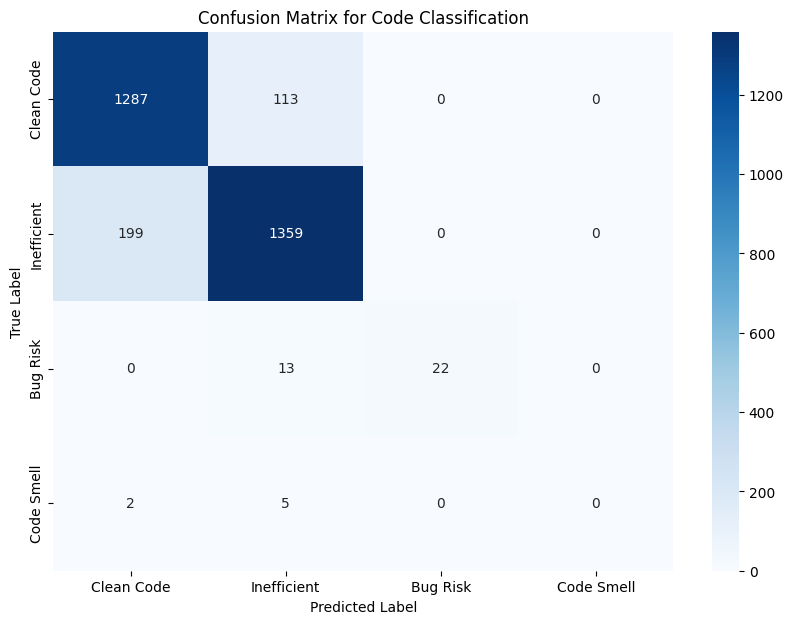

Confusion Matrix saved as 'confusion_matrix.png'


In [27]:
# Define your class names based on Chapter 5
class_names = ["Clean Code", "Inefficient", "Bug Risk", "Code Smell"]

# 1. Compute Confusion Matrix
cm = confusion_matrix(labels, preds)

# 2. Plot using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix for Code Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 3. Save the figure
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show() # This displays it in the notebook
print("Confusion Matrix saved as 'confusion_matrix.png'")

NoteBook 04 : explainability_visualization

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


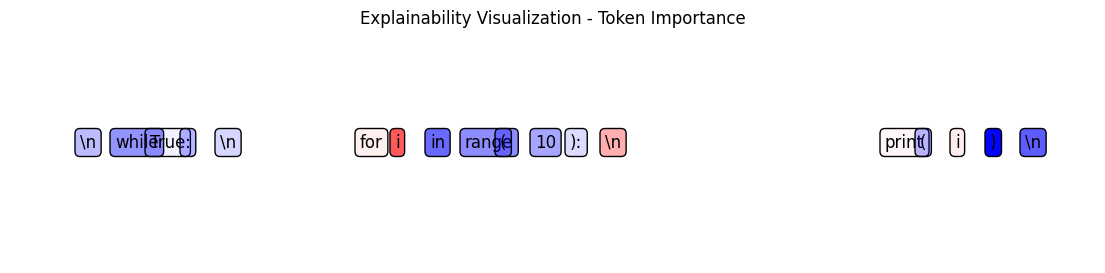

In [28]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from captum.attr import LayerIntegratedGradients

# ============================================
# LOAD MODEL
# ============================================

model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/codebert-base",
    num_labels=4
)

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/codebert-base"
)

model.eval()

# ============================================
# SAMPLE CODE
# ============================================

code_sample = """
while True:
    for i in range(10):
        print(i)
"""

# ============================================
# TOKENIZE
# ============================================

inputs = tokenizer(
    code_sample,
    return_tensors="pt",
    truncation=True
)

input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

# ============================================
# FORWARD FUNCTION
# ============================================

def forward_func(input_ids, attention_mask):

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    return outputs.logits

# ============================================
# CAPTUM
# ============================================

lig = LayerIntegratedGradients(
    forward_func,
    model.roberta.embeddings
)

# Prediction
outputs = model(**inputs)

pred_class = torch.argmax(outputs.logits, dim=1).item()

# Baseline
baseline = torch.zeros_like(input_ids)

# Attribution
attributions, delta = lig.attribute(
    inputs=input_ids,
    baselines=baseline,
    additional_forward_args=(attention_mask,),
    target=pred_class,
    return_convergence_delta=True
)

# ============================================
# PROCESS ATTRIBUTIONS
# ============================================

scores = attributions.sum(dim=-1).squeeze(0)

tokens = tokenizer.convert_ids_to_tokens(
    input_ids.squeeze(0)
)

# Clean tokens
clean_tokens = []

for token in tokens:

    token = token.replace("Ġ", "")
    token = token.replace("Ċ", "\\n")
    token = token.replace("<s>", "")
    token = token.replace("</s>", "")

    clean_tokens.append(token)

# Normalize scores
scores = scores.detach().numpy()

max_score = max(abs(scores))

normalized_scores = scores / max_score

# ============================================
# CREATE HEATMAP VISUALIZATION
# ============================================

fig, ax = plt.subplots(figsize=(14, 3))

for i, (token, score) in enumerate(zip(clean_tokens, normalized_scores)):

    color_intensity = abs(score)

    if score > 0:
        color = (1, 0, 0, color_intensity)  # red
    else:
        color = (0, 0, 1, color_intensity)  # blue

    ax.text(
        i,
        0,
        token,
        fontsize=12,
        bbox=dict(
            facecolor=color,
            edgecolor='black',
            boxstyle='round,pad=0.3'
        )
    )

ax.set_xlim(-1, len(clean_tokens))
ax.set_ylim(-1, 1)

ax.axis('off')

plt.title("Explainability Visualization - Token Importance")

# SAVE IMAGE
plt.savefig("explainability_heatmap.png", bbox_inches='tight')

plt.show()